In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from src.preprocess import preprocess_data


In [2]:
df = pd.read_csv("../data/raw/diabetic_data.csv")
X, y = preprocess_data(df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [3]:
model = joblib.load("../models/best_model.pkl")
model

/Users/pradhyumnakasula/anaconda3/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/pradhyumnakasula/anaconda3/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.3.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/pradhyumnakasula/anaconda3/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from versi

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='i...
                                                   'metformin', 'repaglinide',
                                                   'nateglinide',
                                                   'chlorpropamide',
                                                   'glimepiride',
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin', ...])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [4]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_default))

ROC-AUC: 0.677528904160382
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.63      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.76      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354



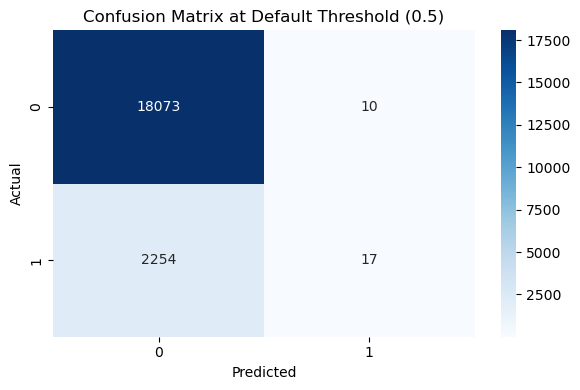

In [5]:
cm = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix at Default Threshold (0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


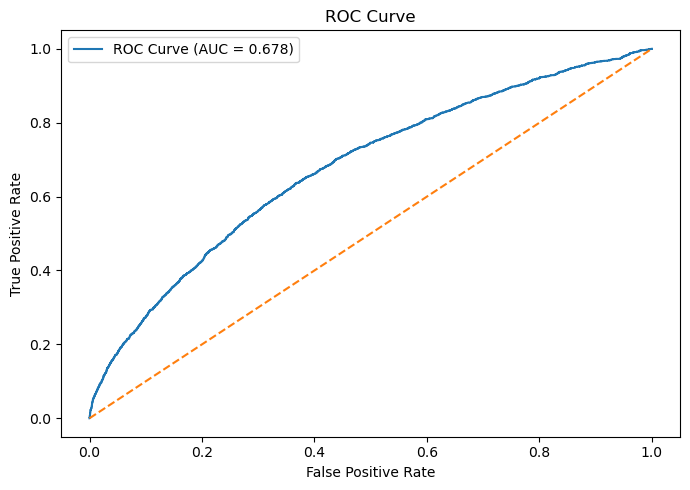

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


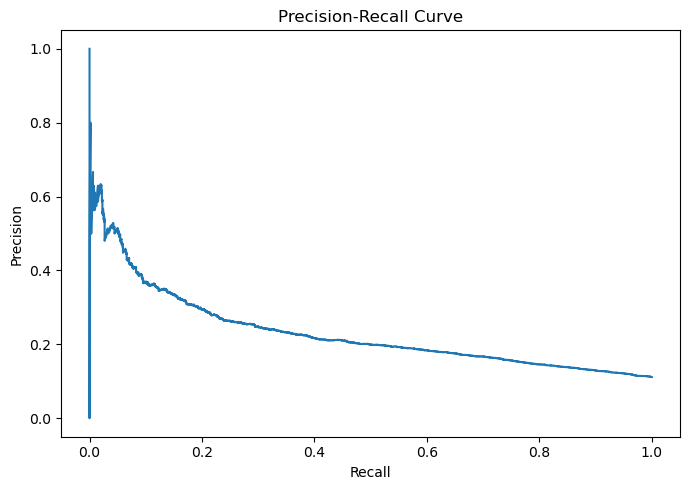

In [7]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()


In [8]:
threshold_results = []
for threshold in np.arange(0.1, 0.91, 0.05):
    y_pred_thresh = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "f1": f1_score(y_test, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.163507,0.717745,0.266340
1,0.15,0.230267,0.357111,0.279993
2,0.20,0.307122,0.182299,0.228792
3,0.25,0.366086,0.101717,0.159201
4,0.30,0.420366,0.070894,0.121326
5,0.35,0.515306,0.044474,0.081881
6,0.40,0.562500,0.023778,0.045627
7,0.45,0.586207,0.014971,0.029197
8,0.50,0.629630,0.007486,0.014795
9,0.55,0.583333,0.003082,0.006132


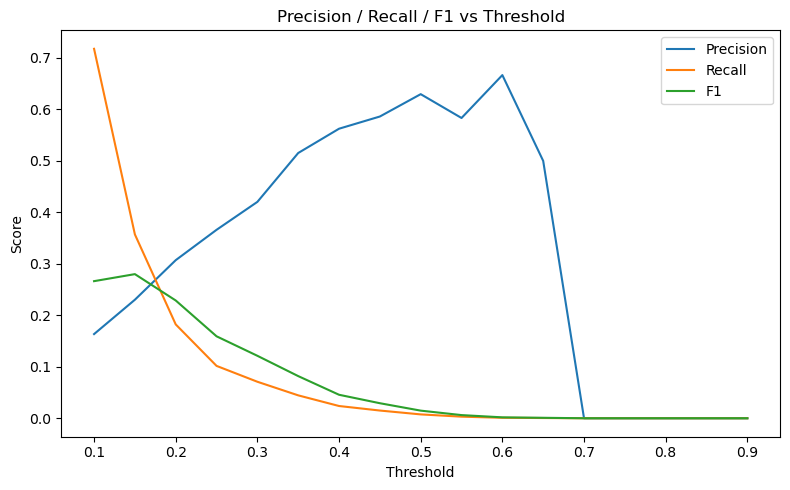

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
best_threshold = 0.20
y_pred_tuned = (y_prob >= best_threshold).astype(int)
print("Threshold:", best_threshold)
print(classification_report(y_test, y_pred_tuned))

Threshold: 0.2
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     18083
           1       0.31      0.18      0.23      2271

    accuracy                           0.86     20354
   macro avg       0.60      0.57      0.58     20354
weighted avg       0.84      0.86      0.85     20354



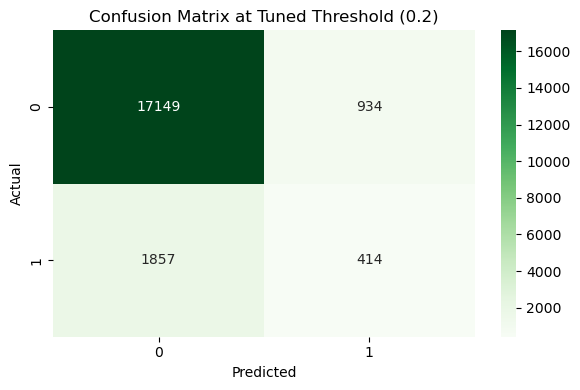

In [11]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens")
plt.title(f"Confusion Matrix at Tuned Threshold ({best_threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [12]:
#comparing default vs tuned 
comparison_df = pd.DataFrame([
    {
        "setting": "default_0.5",
        "precision": precision_score(y_test, y_pred_default, zero_division=0),
        "recall": recall_score(y_test, y_pred_default, zero_division=0),
        "f1": f1_score(y_test, y_pred_default, zero_division=0)
    },
    {
        "setting": f"tuned_{best_threshold}",
        "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
        "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
        "f1": f1_score(y_test, y_pred_tuned, zero_division=0)
    }
])

comparison_df


,setting,precision,recall,f1
0,default_0.5,0.629630,0.007486,0.014795
1,tuned_0.2,0.307122,0.182299,0.228792
